# Experto 4 — LUNA16: DCSwinB-style (Swin 3D + R3D) + Grad-CAM

Notebook de entrenamiento del **Experto 4** del sistema MoE.

- **Origen de datos:** el zip **`Luna16 Lung Cancer Dataset.zip`** en `01_Data/Raw/` (misma convención que `01_Exploracion_Estructura_Datasets.ipynb`). Tras copiarlo a `/content/datasets/` se descomprime en **`/content/datasets/Luna16 Lung Cancer Dataset/`**. Ahí están los **888** `.mhd`, el binario (`.raw`/`.zraw`) y los **CSV del challenge** (`annotations.csv`, `candidates_V2.csv`, etc.); **no se genera ningún CSV nuevo**: solo se leen con `pandas`.
- **Volumen ROI:** cubo **64×64×64** vóxeles tras resample 1 mm y ventana HU (alineado al paper y a la consigna MoE).
- **Etiquetas `class`:** se toman del CSV de candidatos del zip (track reducción de FP: 0/1). No es malignidad LIDC; si más adelante usas `processed_labels.csv` con malignancy, sustituye esa lectura.
- **Arquitectura:** DCSwinB-style — rama Swin-Tiny 3D (timm inflate) + rama CNN R3D-18 (transfer) + fusión; plan B R3D-18 solo.
- **Pesos y métricas (Drive):** `03_Weights/Experts_2D/Expert4_LUNA16/` (`checkpoints/`, `metrics/`, `figures/`). Prefijo de run: `RUN_TAG` en Fase 0 → `expert4_{RUN_TAG}_fold{k}_best.pth`.
- **Entrenamiento:** dos fases (cabeza con backbone congelado → fine-tune con LR por rama Swin/CNN/cabeza), CE ponderada por clase (`balanced`), CV con StratifiedGroupKFold (recomendado ≥5 folds; objetivo F1 > 0.65 evaluado en **media ± std**, no un solo fold).
- **Referencia:** `guides/Luna16/Deep learning-based lung cancer classification of CT images.md`


In [1]:
# Fase 0: Setup & montar Drive
!pip install -q SimpleITK nibabel monai timm scikit-learn tqdm seaborn scipy matplotlib-inline

from google.colab import drive
import os, glob, time, json, shutil, subprocess, random
import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# AMP: usar torch.amp en Fase 5 (torch.cuda.amp está deprecado en PyTorch 2.x)
from torch.utils.checkpoint import checkpoint as grad_checkpoint
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from tqdm.auto import tqdm
# Gráficas dentro del notebook: el backend debe fijarse ANTES de importar pyplot
import matplotlib as mpl
try:
    mpl.use("module://matplotlib_inline.backend_inline")
except Exception:
    try:
        __import__("IPython").get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass
import matplotlib.pyplot as plt
import timm
print("Matplotlib: salida embebida en el notebook (inline). Reinicia el kernel si no ves gráficas.")

drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Misma convención que 01_Exploracion_Estructura_Datasets.ipynb
RAW_DIR = '/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/'
LOCAL_DEST = '/content/datasets/'
LUNA_ZIP_NAME = 'Luna16 Lung Cancer Dataset.zip'
LUNA_FOLDER_NAME = os.path.splitext(LUNA_ZIP_NAME)[0]  # "Luna16 Lung Cancer Dataset"
LUNA_BASE = os.path.join(LOCAL_DEST, LUNA_FOLDER_NAME)

WEIGHTS_BASE = '/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/'
WEIGHTS_DIR = os.path.join(WEIGHTS_BASE, 'Expert4_LUNA16')
# Prefijo de archivos de checkpoint/historial (cámbialo por experimento para no pisar runs previos)
RUN_TAG = 'twophase_wce_v1'
for d in ['checkpoints', 'metrics', 'figures']:
    os.makedirs(os.path.join(WEIGHTS_DIR, d), exist_ok=True)
os.makedirs(LOCAL_DEST, exist_ok=True)
print("Rutas configuradas.")
print(f"  Zip en Drive: {os.path.join(RAW_DIR, LUNA_ZIP_NAME)}")
print(f"  Datos locales (CSV + .mhd vienen dentro del zip): {LUNA_BASE}")
print(f"  Pesos y métricas (Experto 4): {WEIGHTS_DIR}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 43.9 MB/s eta 0:00:00
Matplotlib: salida embebida en el notebook (inline). Reinicia el kernel si no ves gráficas.
Mounted at /content/drive
Device: cuda
Rutas configuradas.
  Zip en Drive: /content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/Luna16 Lung Cancer Dataset.zip
  Datos locales (CSV + .mhd vienen dentro del zip): /content/datasets/Luna16 Lung Cancer Dataset
  Pesos y métricas (Experto 4): /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16


In [2]:
# Fase 1: LUNA16 — mismo flujo que 01_Exploracion_Estructura_Datasets.ipynb
# 1) Copiar el zip desde Drive a /content/datasets/
# 2) Descomprimir en /content/datasets/Luna16 Lung Cancer Dataset/
# 3) Borrar el zip local (libera espacio en Colab)
# Los CSV (annotations, candidates_V2, etc.) ya vienen dentro del zip; no se crean a mano.

FORCE_REUNZIP = False  # True para forzar descompresión aunque existan .mhd

drive_zip_path = os.path.join(RAW_DIR, LUNA_ZIP_NAME)
if not os.path.isfile(drive_zip_path):
    alt = sorted(
        glob.glob(os.path.join(RAW_DIR, '*Luna*.zip')) +
        glob.glob(os.path.join(RAW_DIR, '*luna*.zip'))
    )
    if alt:
        drive_zip_path = alt[0]
        print(f"AVISO: usando zip encontrado: {drive_zip_path}")
    else:
        raise FileNotFoundError(
            f"No está {LUNA_ZIP_NAME} en {RAW_DIR}. Sube el zip o ajusta LUNA_ZIP_NAME."
        )

local_zip_path = os.path.join(LOCAL_DEST, os.path.basename(drive_zip_path))
unzip_dir = os.path.join(LOCAL_DEST, os.path.splitext(os.path.basename(drive_zip_path))[0])

mhd_probe = glob.glob(os.path.join(unzip_dir, '**', '*.mhd'), recursive=True)
if FORCE_REUNZIP or len(mhd_probe) < 100:
    print("1. Copiando zip desde Drive al entorno local...")
    t0 = time.time()
    shutil.copy2(drive_zip_path, local_zip_path)
    print(f"   Copia OK ({time.time()-t0:.1f}s)")

    os.makedirs(unzip_dir, exist_ok=True)
    print(f"2. Descomprimiendo en {unzip_dir} ...")
    t1 = time.time()
    r = subprocess.run(
        ['unzip', '-q', '-o', local_zip_path, '-d', unzip_dir],
        capture_output=True, text=True,
    )
    if r.returncode != 0:
        print("unzip falló, intentando zipfile...")
        import zipfile
        with zipfile.ZipFile(local_zip_path, 'r') as zf:
            zf.extractall(unzip_dir)
    print(f"   Unzip OK ({time.time()-t1:.1f}s)")

    print("3. Borrando zip local...")
    os.remove(local_zip_path)
else:
    print(f"Datos ya presentes en {unzip_dir} ({len(mhd_probe)} .mhd). "
          f"Pon FORCE_REUNZIP=True para volver a extraer.")

LUNA_BASE = unzip_dir  # raíz del dataset descomprimido (incluye CSV del challenge)

mhd_files = sorted(glob.glob(os.path.join(LUNA_BASE, '**', '*.mhd'), recursive=True))
raw_files = sorted(
    glob.glob(os.path.join(LUNA_BASE, '**', '*.raw'), recursive=True)
    + glob.glob(os.path.join(LUNA_BASE, '**', '*.zraw'), recursive=True)
)
csv_files = sorted(glob.glob(os.path.join(LUNA_BASE, '**', '*.csv'), recursive=True))

print(f"\nArchivos encontrados bajo {LUNA_BASE}:")
print(f"  .mhd: {len(mhd_files)}")
print(f"  .raw/.zraw: {len(raw_files)}")
print(f"  .csv: {len(csv_files)}")
for c in csv_files:
    print(f"    {c}")


1. Copiando zip desde Drive al entorno local...
   Copia OK (7.5s)
2. Descomprimiendo en /content/datasets/Luna16 Lung Cancer Dataset ...
   Unzip OK (18.5s)
3. Borrando zip local...

Archivos encontrados bajo /content/datasets/Luna16 Lung Cancer Dataset:
  .mhd: 888
  .raw/.zraw: 888
  .csv: 10
    /content/datasets/Luna16 Lung Cancer Dataset/annotations.csv
    /content/datasets/Luna16 Lung Cancer Dataset/candidates.csv
    /content/datasets/Luna16 Lung Cancer Dataset/candidates_V2/candidates_V2.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/annotations/annotations.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/annotations/annotations_excluded.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/annotations/seriesuids.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/exampleFiles/evaluation/froc_gt_prob_vectors_sampleSubmission.csv
   

In [3]:
# --- Descubrimiento: ¿dónde está la etiqueta del dataset? (CSV vs .mhd) ---
# Ejecutar después de la Fase 1 (tener LUNA_BASE, mhd_files, csv_files definidos).

print("=" * 70)
print("ETIQUETAS LUNA16: ¿en el CSV o en el volumen .mhd?")
print("=" * 70)

print("""
Resumen esperado (challenge LUNA16):
- Los archivos .mhd (+ .raw/.zraw) son SOLO imágenes CT (valores HU, geometría).
  No incluyen la etiqueta de clase del track de candidatos ni malignidad clínica.
- Las columnas de coordenadas y la columna `class` (0/1) vienen en los CSV del zip,
  en particular candidates / candidates_V2 para el track de falsos positivos.
- annotations.csv da posición y tamaño del nódulo de referencia (detección), no
  benigno/maligno al estilo LIDC.
""")

print("\n[1] CSV encontrados en el dataset descomprimido:\n")
for cpath in csv_files:
    bn = os.path.basename(cpath)
    try:
        df = pd.read_csv(cpath, nrows=5)
        cols = list(df.columns)
        print(f"  • {bn}")
        print(f"    columnas ({len(cols)}): {cols}")
        if "class" in [x.lower() for x in cols]:
            print("    → contiene columna 'class' (etiqueta 0/1 por candidato).")
        if "malign" in " ".join(cols).lower():
            print("    → contiene algo relacionado con malignidad (revisar).")
    except Exception as e:
        print(f"  • {bn}  ERROR leyendo: {e}")

print("\n[2] Un archivo .mhd de ejemplo (metadatos SimpleITK):\n")
if mhd_files:
    sample_mhd = mhd_files[0]
    print(f"  Archivo: {sample_mhd}")
    img = sitk.ReadImage(sample_mhd)
    keys = list(img.GetMetaDataKeys())
    print(f"  Número de claves de metadatos: {len(keys)}")
    for k in keys[:25]:
        try:
            v = img.GetMetaData(k)
            if len(v) > 80:
                v = v[:77] + "..."
            print(f"    {k}: {v}")
        except Exception:
            print(f"    {k}: <no legible>")
    if len(keys) > 25:
        print(f"    ... y {len(keys)-25} claves más.")
    print("""
  Interpretación: suele haber DICOM/Series UID, espaciado, etc. No esperes una
  columna 'label' o 'cancer' aquí salvo que tu pipeline haya escrito algo
  personalizado (p. ej. otro notebook que añadió RouterLabel al convertir a .mha).
""")
else:
    print("  (No hay .mhd todavía — ejecuta la celda de descompresión primero.)")

print("\n[3] Conclusión para este notebook:\n")
print("  → La etiqueta que usa el DataLoader (columna `label`) se arma leyendo")
print("    el CSV de candidatos con `class`, NO leyendo el .mhd.")
print("  → Si necesitas benigno/maligno como en papers con LIDC, hay que unir")
print("    con tablas de malignancy externas o un CSV procesado aparte.\n")
print("=" * 70)


ETIQUETAS LUNA16: ¿en el CSV o en el volumen .mhd?

Resumen esperado (challenge LUNA16):
- Los archivos .mhd (+ .raw/.zraw) son SOLO imágenes CT (valores HU, geometría).
  No incluyen la etiqueta de clase del track de candidatos ni malignidad clínica.
- Las columnas de coordenadas y la columna `class` (0/1) vienen en los CSV del zip,
  en particular candidates / candidates_V2 para el track de falsos positivos.
- annotations.csv da posición y tamaño del nódulo de referencia (detección), no
  benigno/maligno al estilo LIDC.


[1] CSV encontrados en el dataset descomprimido:

  • annotations.csv
    columnas (5): ['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']
  • candidates.csv
    columnas (5): ['seriesuid', 'coordX', 'coordY', 'coordZ', 'class']
    → contiene columna 'class' (etiqueta 0/1 por candidato).
  • candidates_V2.csv
    columnas (5): ['seriesuid', 'coordX', 'coordY', 'coordZ', 'class']
    → contiene columna 'class' (etiqueta 0/1 por candidato).
  • annotations.cs

In [4]:
# Fase 2: Leer CSVs que ya vienen en el zip (no generamos ningún CSV en disco)
# - annotations.csv: referencia de detección (coords mundo, diámetro)
# - candidates_V2.csv: track FP reduction (class 0 = no-nódulo, 1 = nódulo)
# Malignidad binaria estilo paper DCSwinB requiere tablas LIDC aparte; aquí usamos
# las etiquetas del challenge oficial en candidates_V2 cuando exista.

def _normalize_luna_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    lower = {c.lower(): c for c in df.columns}
    ren = {}
    if 'seriesuid' not in lower and 'seriesinstanceuid' in lower:
        ren[lower['seriesinstanceuid']] = 'seriesuid'
    for a, b in [('coordx', 'coordX'), ('coordy', 'coordY'), ('coordz', 'coordZ')]:
        if a in lower and b not in lower:
            ren[lower[a]] = b
    for old, new in ren.items():
        df = df.rename(columns={old: new})
    return df

ann_path = os.path.join(LUNA_BASE, 'annotations.csv')
if not os.path.isfile(ann_path):
    ann_path = next((c for c in csv_files if 'annotations' in os.path.basename(c).lower()
                     and 'excluded' not in os.path.basename(c).lower()), None)

cand_path = os.path.join(LUNA_BASE, 'candidates_V2.csv')
if not os.path.isfile(cand_path):
    cand_path = next((c for c in csv_files if 'candidates_v2' in os.path.basename(c).lower()), None)
if cand_path is None or not os.path.isfile(str(cand_path)):
    cand_path = next((c for c in csv_files if 'candidates' in os.path.basename(c).lower()), None)

print(f"annotations.csv: {ann_path}")
print(f"candidates CSV:  {cand_path}")

annotations = pd.read_csv(ann_path) if ann_path and os.path.isfile(str(ann_path)) else pd.DataFrame()
if len(annotations) > 0:
    annotations = _normalize_luna_columns(annotations)
print(f"Filas en annotations (referencia detección): {len(annotations)}")
if len(annotations) > 0:
    print(annotations.head())

uid_to_mhd = {}
for mhd in mhd_files:
    uid = os.path.splitext(os.path.basename(mhd))[0]
    uid_to_mhd[uid] = mhd

if cand_path is not None and os.path.isfile(str(cand_path)):
    candidates = pd.read_csv(cand_path)
    candidates = _normalize_luna_columns(candidates)
    candidates['class'] = pd.to_numeric(candidates['class'], errors='coerce').fillna(0).astype(int)
    print(f"\nCandidates (desde zip) shape: {candidates.shape}")
    print(candidates.head())
    nodules = candidates[candidates['class'] == 1].copy()
    non_nodules = candidates[candidates['class'] == 0].copy()
    max_neg = min(len(non_nodules), len(nodules) * 2)
    non_nodules = non_nodules.sample(n=max_neg, random_state=SEED)
    df_labels = pd.concat([nodules, non_nodules], ignore_index=True)
    df_labels = df_labels.rename(columns={'class': 'label'})
elif len(annotations) > 0:
    df_labels = annotations.copy()
    df_labels['label'] = 1
    print("AVISO: no hay candidates*.csv; usando solo annotations (todos label=1).")
else:
    raise FileNotFoundError("No se encontraron CSV dentro del dataset descomprimido.")

df_labels['mhd_path'] = df_labels['seriesuid'].astype(str).map(uid_to_mhd)
df_labels = df_labels.dropna(subset=['mhd_path'])

df_labels['group_id'] = df_labels['seriesuid'].astype(str)

print(f"\nMuestras listas para entrenamiento: {len(df_labels)}")
print(f"Distribución de label:\n{df_labels['label'].value_counts()}")
print(f"Series únicas (group_id): {df_labels['group_id'].nunique()}")


annotations.csv: /content/datasets/Luna16 Lung Cancer Dataset/annotations.csv
candidates CSV:  /content/datasets/Luna16 Lung Cancer Dataset/candidates_V2/candidates_V2.csv
Filas en annotations (referencia detección): 1186
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  

Candidates (desde zip) shape: (754975, 5)
                                           seriesuid     coordX      coordY  \
0

In [5]:
# Fase 3: Dataset — carga volumen, resample, HU clip, min-max, ROI 64³
ROI_SIZE = (64, 64, 64)
HU_MIN, HU_MAX = -1000.0, 400.0


def extract_roi_volume_np(row):
    """Un ROI 64³ normalizado [0,1] desde una fila de df_labels. Shape (64,64,64) float32."""
    mhd_path = row['mhd_path']
    try:
        img = sitk.ReadImage(mhd_path)
        orig_spacing = np.array(img.GetSpacing())
        orig_size = np.array(img.GetSize())
        new_spacing = np.array([1.0, 1.0, 1.0])
        new_size = (orig_size * orig_spacing / new_spacing).astype(int).tolist()

        resampler = sitk.ResampleImageFilter()
        resampler.SetOutputSpacing(new_spacing.tolist())
        resampler.SetSize(new_size)
        resampler.SetInterpolator(sitk.sitkLinear)
        resampler.SetOutputOrigin(img.GetOrigin())
        resampler.SetOutputDirection(img.GetDirection())
        img = resampler.Execute(img)

        vol = sitk.GetArrayFromImage(img).astype(np.float32)

        vol = np.clip(vol, HU_MIN, HU_MAX)
        vol = (vol - HU_MIN) / (HU_MAX - HU_MIN)

        world_coord = np.array([row['coordX'], row['coordY'], row['coordZ']])
        voxel_coord = img.TransformPhysicalPointToIndex(world_coord.tolist())
        cz, cy, cx = voxel_coord[2], voxel_coord[1], voxel_coord[0]

        half = 32
        d, h, w = vol.shape
        z0 = max(0, cz - half); z1 = z0 + 64
        y0 = max(0, cy - half); y1 = y0 + 64
        x0 = max(0, cx - half); x1 = x0 + 64

        if z1 > d: z0 = max(0, d - 64); z1 = d
        if y1 > h: y0 = max(0, h - 64); y1 = h
        if x1 > w: x0 = max(0, w - 64); x1 = w

        roi = vol[z0:z1, y0:y1, x0:x1]

        pad_d = 64 - roi.shape[0]
        pad_h = 64 - roi.shape[1]
        pad_w = 64 - roi.shape[2]
        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            roi = np.pad(roi, ((0, pad_d), (0, pad_h), (0, pad_w)), mode='constant')

        return roi.astype(np.float32)
    except Exception as e:
        print(f"Error cargando {mhd_path}: {e}")
        return np.zeros((64, 64, 64), dtype=np.float32)


class LUNA16NoduleDataset(Dataset):
    def __init__(self, df, augment=False):
        self.records = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        label = int(row['label'])
        roi = extract_roi_volume_np(row)
        tensor = torch.from_numpy(np.ascontiguousarray(roi)).unsqueeze(0)

        if self.augment:
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[1])
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[2])
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[3])

        return tensor, label

# Test rápido
_test_ds = LUNA16NoduleDataset(df_labels.head(2))
_t, _l = _test_ds[0]
print(f"Test shape: {_t.shape}, label: {_l}, min={_t.min():.3f}, max={_t.max():.3f}")


Test shape: torch.Size([1, 64, 64, 64]), label: 1, min=0.714, max=0.716


In [6]:
# Fase 3B: Materializar ROIs 64³ en disco + dataset que solo lee .npz (acelera train/val)

ROI_CACHE_DIR = os.path.join(LOCAL_DEST, 'Luna16_ROI_cache_v1')
FORCE_REBUILD_ROI_CACHE = False  # True para regenerar todo el caché


def materialize_roi_cache(df_labels, cache_dir, force=False):
    """Escribe roi_{idx:06d}.npz con Z (64,64,64) y y (escalar), idx = posición en df_labels."""
    os.makedirs(cache_dir, exist_ok=True)
    n = len(df_labels)
    for idx in tqdm(range(n), desc='Materializando ROI cache'):
        out_path = os.path.join(cache_dir, f'roi_{idx:06d}.npz')
        if os.path.isfile(out_path) and not force:
            continue
        row = df_labels.iloc[idx]
        vol = extract_roi_volume_np(row)
        np.savez_compressed(
            out_path,
            Z=vol.astype(np.float32),
            y=np.int64(int(row['label'])),
        )
    meta = {'version': 'v1', 'n_rows': n, 'roi_shape': list(ROI_SIZE)}
    with open(os.path.join(cache_dir, 'meta.json'), 'w') as f:
        json.dump(meta, f, indent=2)
    print(f"Caché listo: {cache_dir} ({n} ROIs)")


def roi_cache_matches_df(cache_dir, n_expected):
    p = os.path.join(cache_dir, 'meta.json')
    if not os.path.isfile(p):
        return False
    with open(p) as f:
        m = json.load(f)
    return int(m.get('n_rows', -1)) == int(n_expected)


class LUNA16CachedROIDataset(Dataset):
    """Subconjunto por índices globales en df_labels; archivos roi_{global_idx}.npz."""

    def __init__(self, df_full, index_array, cache_dir, augment=False):
        self.df_full = df_full
        self.indices = np.asarray(index_array, dtype=np.int64)
        self.cache_dir = cache_dir
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        gidx = int(self.indices[i])
        path = os.path.join(self.cache_dir, f'roi_{gidx:06d}.npz')
        data = np.load(path)
        z = np.ascontiguousarray(data['Z'])
        label = int(data['y'])
        tensor = torch.from_numpy(z).unsqueeze(0).float()
        if self.augment:
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[1])
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[2])
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[3])
        return tensor, label


USE_ROI_CACHE = True
ROI_CACHE_READY = False
if USE_ROI_CACHE:
    if FORCE_REBUILD_ROI_CACHE or not roi_cache_matches_df(ROI_CACHE_DIR, len(df_labels)):
        materialize_roi_cache(df_labels, ROI_CACHE_DIR, force=FORCE_REBUILD_ROI_CACHE)
    ROI_CACHE_READY = roi_cache_matches_df(ROI_CACHE_DIR, len(df_labels))
    if ROI_CACHE_READY:
        print(f"USE_ROI_CACHE=True — usando {ROI_CACHE_DIR}")
    else:
        print("AVISO: caché incompleto; Fase 5 usará LUNA16NoduleDataset on-the-fly.")
else:
    print("USE_ROI_CACHE=False — lectura on-the-fly desde .mhd en train/val.")


Materializando ROI cache:   0%|          | 0/4671 [00:00<?, ?it/s]

Caché listo: /content/datasets/Luna16_ROI_cache_v1 (4671 ROIs)
USE_ROI_CACHE=True — usando /content/datasets/Luna16_ROI_cache_v1


In [7]:
# Fase 4: Modelo — DCSwinB-style (rama Swin 3D timm + rama CNN R3D-18 + fusión) + plan B R3D-18
from torchvision.models.video import r3d_18, R3D_18_Weights

USE_DCSWIN_STYLE = True  # False → solo plan B R3D-18
USE_SWIN_3D = USE_DCSWIN_STYLE  # alias para celdas que aún usen el nombre antiguo


class DCSwinBStyle3D(nn.Module):
    """Dual-branch estilo DCSwinB: Swin-Tiny 3D (inflate timm) + CNN 3D (stem+layer1+layer2 de R3D-18).
    Transfer: pesos ImageNet/timm en Swin; Kinetics/ImageNet-Video en rama R3D.
    Conv-MLP ligero: depthwise 3×3×3 tras patch_embed (residual).
    """
    def __init__(self, num_classes=2, pretrained=True, use_dwconv_mix=True):
        super().__init__()
        self.use_dwconv_mix = use_dwconv_mix
        swin2d = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained, num_classes=0, img_size=256,
        )
        old_proj = swin2d.patch_embed.proj
        C_out = old_proj.out_channels
        self.patch_embed_3d = nn.Conv3d(1, C_out, kernel_size=(4, 4, 4), stride=(4, 4, 4), padding=0)
        w2d = old_proj.weight.data
        w_mean = w2d.mean(dim=1, keepdim=True)
        w3d = w_mean.unsqueeze(2).expand(-1, -1, 4, -1, -1) / 4.0
        self.patch_embed_3d.weight.data.copy_(w3d)
        if old_proj.bias is not None:
            self.patch_embed_3d.bias.data.copy_(old_proj.bias.data)
        if use_dwconv_mix:
            self.dw_mix = nn.Conv3d(C_out, C_out, 3, padding=1, groups=C_out, bias=True)
            nn.init.zeros_(self.dw_mix.weight)
            if self.dw_mix.bias is not None:
                nn.init.zeros_(self.dw_mix.bias)
        else:
            self.dw_mix = None
        self.patch_embed_norm = swin2d.patch_embed.norm
        self.layers = swin2d.layers
        self.norm = swin2d.norm
        self.swin_dim = swin2d.num_features
        del swin2d
        w = R3D_18_Weights.DEFAULT if pretrained else None
        base = r3d_18(weights=w)
        oc = base.stem[0]
        conv1 = nn.Conv3d(
            1, 64, kernel_size=oc.kernel_size, stride=oc.stride, padding=oc.padding, bias=False,
        )
        with torch.no_grad():
            conv1.weight.copy_(oc.weight.mean(dim=1, keepdim=True))
        # Stem R3D: Conv3d + BN + ReLU (3 módulos; sin MaxPool extra en torchvision reciente)
        self.cnn_branch = nn.Sequential(
            conv1, base.stem[1], base.stem[2],
            base.layer1, base.layer2,
            nn.AdaptiveAvgPool3d(1), nn.Flatten(),
        )
        self.cnn_dim = 128
        del base
        self.head = nn.Linear(self.swin_dim + self.cnn_dim, num_classes)
        self.num_features = self.swin_dim + self.cnn_dim

    def forward(self, x):
        z_cnn = self.cnn_branch(x)
        t = self.patch_embed_3d(x)
        if self.dw_mix is not None:
            t = t + self.dw_mix(t)
        B, C, D, H, W = t.shape
        t = t.view(B, C, 4, 4, H, W)
        t = t.permute(0, 1, 2, 4, 3, 5)
        t = t.reshape(B, C, 4 * H, 4 * W)
        t = t.permute(0, 2, 3, 1)
        t = self.patch_embed_norm(t)
        for layer in self.layers:
            t = grad_checkpoint(layer, t, use_reentrant=False)
        t = self.norm(t)
        z_swin = t.mean(dim=[1, 2])
        z = torch.cat([z_swin, z_cnn], dim=1)
        return self.head(z)

# Plan B: R3D-18 (si el modelo dual falla en shapes/VRAM)
class R3D18Expert(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        from torchvision.models.video import r3d_18, R3D_18_Weights
        base = r3d_18(weights=R3D_18_Weights.DEFAULT)
        old_conv = base.stem[0]
        self.stem_conv = nn.Conv3d(1, 64, kernel_size=(3,7,7),
                                   stride=(1,2,2), padding=(1,3,3), bias=False)
        w = old_conv.weight.data.mean(dim=1, keepdim=True)
        self.stem_conv.weight.data.copy_(w)
        base.stem[0] = self.stem_conv
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head = nn.Linear(512, num_classes)

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head(feat)

# Probar DCSwinB-style primero
try:
    if USE_DCSWIN_STYLE:
        model = DCSwinBStyle3D(num_classes=2, pretrained=True).to(DEVICE)
        dummy = torch.randn(1, 1, 64, 64, 64).to(DEVICE)
        with torch.no_grad():
            out = model(dummy)
        print(f"DCSwinBStyle3D OK — output shape: {out.shape}")
        del dummy, out
    else:
        raise RuntimeError("Usando plan B por configuración")
except Exception as e:
    print(f"DCSwinBStyle3D falló ({e}), usando R3D-18 (plan B)")
    model = R3D18Expert(num_classes=2).to(DEVICE)
    dummy = torch.randn(1, 1, 64, 64, 64).to(DEVICE)
    with torch.no_grad():
        out = model(dummy)
    print(f"R3D18Expert OK — output shape: {out.shape}")
    del dummy, out

n_params = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params: {n_params:,} total | {n_train:,} entrenables")
torch.cuda.empty_cache()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:01<00:00, 121MB/s]


DCSwinBStyle3D OK — output shape: torch.Size([1, 2])
Params: 29,535,548 total | 29,535,548 entrenables


In [8]:
# Fase 5: StratifiedGroupKFold + AMP + dos fases (cabeza vs backbone) + CE ponderada
# Checkpoints: expert4_{RUN_TAG}_fold{k}_best.pth | historial: history_{RUN_TAG}_fold_{k}.json

from sklearn.utils.class_weight import compute_class_weight
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

if 'RUN_TAG' not in globals():
    RUN_TAG = 'twophase_wce_v1'


def _labels_to_device(y, device):
    """Evita torch.tensor(tensor) y copias innecesarias (UserWarning PyTorch)."""
    if isinstance(y, torch.Tensor):
        return y.to(device=device, dtype=torch.long).reshape(-1)
    return torch.as_tensor(np.asarray(y), dtype=torch.long, device=device)


def _make_class_weight_tensor(train_labels, device):
    """Cross-entropy ponderada: pesos 'balanced' según frecuencia por clase en el train del fold."""
    y = np.asarray(train_labels).reshape(-1)
    classes = np.array([0, 1])
    w = compute_class_weight('balanced', classes=classes, y=y)
    return torch.tensor(w, dtype=torch.float32, device=device)


def _freeze_dcswin_phase_a(m, train_swin_norm=True):
    for p in m.parameters():
        p.requires_grad = False
    for p in m.head.parameters():
        p.requires_grad = True
    if train_swin_norm and getattr(m, 'norm', None) is not None:
        for p in m.norm.parameters():
            p.requires_grad = True


def _unfreeze_all(m):
    for p in m.parameters():
        p.requires_grad = True


def _freeze_r3d_phase_a(m):
    for p in m.parameters():
        p.requires_grad = False
    for p in m.head.parameters():
        p.requires_grad = True


def _param_groups_dcswin(m, lr_swin, lr_cnn, lr_head, wd):
    swin_p, cnn_p, head_p = [], [], []
    for name, p in m.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith('head'):
            head_p.append(p)
        elif 'cnn_branch' in name:
            cnn_p.append(p)
        else:
            swin_p.append(p)
    return [
        {'params': swin_p, 'lr': lr_swin, 'weight_decay': wd},
        {'params': cnn_p, 'lr': lr_cnn, 'weight_decay': wd},
        {'params': head_p, 'lr': lr_head, 'weight_decay': wd},
    ]


def _param_groups_r3d(m, lr_bb, lr_head, wd):
    bb, hd = [], []
    for name, p in m.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith('head'):
            hd.append(p)
        else:
            bb.append(p)
    return [
        {'params': bb, 'lr': lr_bb, 'weight_decay': wd},
        {'params': hd, 'lr': lr_head, 'weight_decay': wd},
    ]


def _validate_epoch(model, val_loader, criterion, amp_device, amp_enabled):
    model.eval()
    val_loss_sum = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        val_pbar = tqdm(val_loader, leave=True, mininterval=0.5)
        for x, y in val_pbar:
            x = x.to(DEVICE)
            y = _labels_to_device(y, DEVICE)
            with torch.amp.autocast(amp_device, enabled=amp_enabled):
                logits = model(x)
                loss = criterion(logits, y)
            val_loss_sum += loss.item() * x.size(0)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            val_pbar.set_postfix(loss=f"{loss.item():.4f}")
    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_cls = f1_score(all_labels, all_preds, labels=[0, 1], average=None, zero_division=0)
    return val_loss, val_acc, val_f1, f1_cls


# --- Hiperparámetros (ajusta VRAM/tiempo/curvas; N_FOLDS alto reduce varianza del CV) ---
BATCH_SIZE = 4
ACCUM_STEPS = 1
PHASE_A_EPOCHS = 8
PHASE_B_EPOCHS = 42
LR_HEAD_PHASE_A = 1e-3
PHASE_A_TRAIN_SWIN_NORM = True
WD = 1e-2
LR_SWIN_B = 3e-5
LR_CNN_B = 5e-5
LR_HEAD_B = 1e-4
WARMUP_FRAC_B = 0.05
EARLY_STOP_PATIENCE_B = 15
N_FOLDS = 3
TARGET_F1_CV = 0.65
TOTAL_EPOCHS_PER_FOLD = PHASE_A_EPOCHS + PHASE_B_EPOCHS
AMP_ENABLED = torch.cuda.is_available()
_AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

scaler = torch.amp.GradScaler(_AMP_DEVICE, enabled=AMP_ENABLED)

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
labels_arr = df_labels['label'].values
groups_arr = df_labels['group_id'].values

all_fold_metrics = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(
        np.zeros(len(df_labels)), labels_arr, groups_arr)):

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*60}")

    train_df = df_labels.iloc[train_idx]
    val_df = df_labels.iloc[val_idx]
    print(f"Train: {len(train_df)} (pos={train_df['label'].sum()}) | "
          f"Val: {len(val_df)} (pos={val_df['label'].sum()})")

    if USE_ROI_CACHE and ROI_CACHE_READY:
        train_ds = LUNA16CachedROIDataset(df_labels, train_idx, ROI_CACHE_DIR, augment=True)
        val_ds = LUNA16CachedROIDataset(df_labels, val_idx, ROI_CACHE_DIR, augment=False)
    else:
        train_ds = LUNA16NoduleDataset(train_df, augment=True)
        val_ds = LUNA16NoduleDataset(val_df, augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    try:
        if USE_DCSWIN_STYLE:
            model = DCSwinBStyle3D(num_classes=2, pretrained=True).to(DEVICE)
        else:
            raise RuntimeError()
    except Exception:
        model = R3D18Expert(num_classes=2).to(DEVICE)

    class_w = _make_class_weight_tensor(train_df['label'].values, DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_w)

    best_val_f1 = 0.0
    best_epoch = -1
    best_f1_per_class = None
    history = {
        'train_loss': [], 'val_loss': [], 'train_acc': [],
        'val_acc': [], 'val_f1': [], 'val_f1_class0': [], 'val_f1_class1': [],
        'phase': [], 'epoch_global': [],
    }

    epoch_global = 0
    is_dcswin = isinstance(model, DCSwinBStyle3D)

    # ---------- Fase A: congelar backbone; entrenar cabeza (y opcional norm Swin) ----------
    if is_dcswin:
        _freeze_dcswin_phase_a(model, train_swin_norm=PHASE_A_TRAIN_SWIN_NORM)
    else:
        _freeze_r3d_phase_a(model)

    if is_dcswin and PHASE_A_TRAIN_SWIN_NORM:
        opt_params = list(model.head.parameters()) + list(model.norm.parameters())
    else:
        opt_params = list(model.head.parameters())

    optimizer = torch.optim.AdamW(opt_params, lr=LR_HEAD_PHASE_A, weight_decay=WD)
    scheduler_a = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(1, PHASE_A_EPOCHS))

    for epoch in range(PHASE_A_EPOCHS):
        epoch_global += 1
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        optimizer.zero_grad(set_to_none=True)
        step_in_accum = 0
        pbar = tqdm(train_loader, desc=f"F{fold_idx+1} A {epoch+1}/{PHASE_A_EPOCHS}", leave=True, mininterval=0.5)
        for x, y in pbar:
            x = x.to(DEVICE)
            y = _labels_to_device(y, DEVICE)
            with torch.amp.autocast(_AMP_DEVICE, enabled=AMP_ENABLED):
                logits = model(x)
                loss = criterion(logits, y) / ACCUM_STEPS
            scaler.scale(loss).backward()
            step_in_accum += 1
            running_loss += loss.item() * ACCUM_STEPS * x.size(0)
            pred = logits.argmax(1)
            train_correct += (pred == y).sum().item()
            train_total += y.size(0)
            pbar.set_postfix(loss=f"{loss.item() * ACCUM_STEPS:.4f}")
            if step_in_accum % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
        if step_in_accum % ACCUM_STEPS != 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        scheduler_a.step()
        train_loss = running_loss / len(train_ds)
        train_acc = train_correct / max(train_total, 1)

        print(
            f"  → Validación Fase A época {epoch+1}: {len(val_ds)} muestras, {len(val_loader)} batches...",
            flush=True,
        )
        val_loss, val_acc, val_f1, f1_cls = _validate_epoch(
            model, val_loader, criterion, _AMP_DEVICE, AMP_ENABLED)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_f1_class0'].append(float(f1_cls[0]))
        history['val_f1_class1'].append(float(f1_cls[1]))
        history['phase'].append('A')
        history['epoch_global'].append(epoch_global)

        print(
            f"  Fold {fold_idx+1} | A {epoch+1:3d}/{PHASE_A_EPOCHS} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"val_f1(macro)={val_f1:.4f} | f1_cls=[{f1_cls[0]:.4f},{f1_cls[1]:.4f}]"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch_global
            best_f1_per_class = [float(f1_cls[0]), float(f1_cls[1])]
            ckpt_path = os.path.join(
                WEIGHTS_DIR, 'checkpoints', f'expert4_{RUN_TAG}_fold{fold_idx}_best.pth')
            payload = {
                'state_dict': model.state_dict(),
                'fold': fold_idx,
                'epoch': best_epoch,
                'phase': 'A',
                'val_f1_macro': float(val_f1),
                'val_f1_per_class': best_f1_per_class,
                'val_acc': float(val_acc),
                'train_loss': float(train_loss),
                'val_loss': float(val_loss),
                'model': 'DCSwinBStyle3D' if is_dcswin else 'R3D18',
                'class_weights': class_w.detach().cpu().tolist(),
            }
            torch.save(payload, ckpt_path)
            print(f"    → Mejor checkpoint: {ckpt_path} (val_f1={val_f1:.4f})")

    # ---------- Fase B: todo descongelado; LR por grupo (Swin / CNN / head); warmup + cosine ----------
    _unfreeze_all(model)
    if is_dcswin:
        param_groups = _param_groups_dcswin(model, LR_SWIN_B, LR_CNN_B, LR_HEAD_B, WD)
    else:
        param_groups = _param_groups_r3d(model, min(LR_SWIN_B, LR_CNN_B), LR_HEAD_B, WD)

    optimizer = torch.optim.AdamW(param_groups)
    warmup_epochs = max(1, int(PHASE_B_EPOCHS * WARMUP_FRAC_B))
    cosine_epochs = max(1, PHASE_B_EPOCHS - warmup_epochs)
    warmup_sched = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs)
    cosine_sched = CosineAnnealingLR(optimizer, T_max=cosine_epochs)
    scheduler_b = SequentialLR(optimizer, [warmup_sched, cosine_sched], milestones=[warmup_epochs])

    epochs_no_improve = 0
    for epoch in range(PHASE_B_EPOCHS):
        epoch_global += 1
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        optimizer.zero_grad(set_to_none=True)
        step_in_accum = 0
        pbar = tqdm(train_loader, desc=f"F{fold_idx+1} B {epoch+1}/{PHASE_B_EPOCHS}", leave=True, mininterval=0.5)
        for x, y in pbar:
            x = x.to(DEVICE)
            y = _labels_to_device(y, DEVICE)
            with torch.amp.autocast(_AMP_DEVICE, enabled=AMP_ENABLED):
                logits = model(x)
                loss = criterion(logits, y) / ACCUM_STEPS
            scaler.scale(loss).backward()
            step_in_accum += 1
            running_loss += loss.item() * ACCUM_STEPS * x.size(0)
            pred = logits.argmax(1)
            train_correct += (pred == y).sum().item()
            train_total += y.size(0)
            pbar.set_postfix(loss=f"{loss.item() * ACCUM_STEPS:.4f}")
            if step_in_accum % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
        if step_in_accum % ACCUM_STEPS != 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        scheduler_b.step()
        train_loss = running_loss / len(train_ds)
        train_acc = train_correct / max(train_total, 1)

        print(
            f"  → Validación Fase B época {epoch+1}: {len(val_ds)} muestras...",
            flush=True,
        )
        val_loss, val_acc, val_f1, f1_cls = _validate_epoch(
            model, val_loader, criterion, _AMP_DEVICE, AMP_ENABLED)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_f1_class0'].append(float(f1_cls[0]))
        history['val_f1_class1'].append(float(f1_cls[1]))
        history['phase'].append('B')
        history['epoch_global'].append(epoch_global)

        print(
            f"  Fold {fold_idx+1} | B {epoch+1:3d}/{PHASE_B_EPOCHS} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"val_f1(macro)={val_f1:.4f} | f1_cls=[{f1_cls[0]:.4f},{f1_cls[1]:.4f}]"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch_global
            best_f1_per_class = [float(f1_cls[0]), float(f1_cls[1])]
            ckpt_path = os.path.join(
                WEIGHTS_DIR, 'checkpoints', f'expert4_{RUN_TAG}_fold{fold_idx}_best.pth')
            payload = {
                'state_dict': model.state_dict(),
                'fold': fold_idx,
                'epoch': best_epoch,
                'phase': 'B',
                'val_f1_macro': float(val_f1),
                'val_f1_per_class': best_f1_per_class,
                'val_acc': float(val_acc),
                'train_loss': float(train_loss),
                'val_loss': float(val_loss),
                'model': 'DCSwinBStyle3D' if is_dcswin else 'R3D18',
                'class_weights': class_w.detach().cpu().tolist(),
            }
            torch.save(payload, ckpt_path)
            print(f"    → Mejor checkpoint: {ckpt_path} (val_f1={val_f1:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if EARLY_STOP_PATIENCE_B is not None and epochs_no_improve >= EARLY_STOP_PATIENCE_B:
                print(f"    Early stopping Fase B (sin mejora {EARLY_STOP_PATIENCE_B} épocas).")
                break

    fold_metrics = {
        'fold': fold_idx,
        'best_val_f1': best_val_f1,
        'best_epoch': best_epoch,
        'best_f1_per_class': best_f1_per_class,
        'final_val_acc': history['val_acc'][-1],
        'final_val_f1': history['val_f1'][-1],
    }
    all_fold_metrics.append(fold_metrics)
    print(f"Fold {fold_idx+1} finalizado — mejor val_f1={best_val_f1:.4f} (época global {best_epoch})")

    hist_path = os.path.join(WEIGHTS_DIR, 'metrics', f'history_{RUN_TAG}_fold_{fold_idx}.json')
    with open(hist_path, 'w') as f:
        json.dump(history, f, indent=2)

print(f"\n{'='*60}")
print("RESUMEN CROSS-VALIDATION")
print(f"{'='*60}")
f1s = [m['best_val_f1'] for m in all_fold_metrics]
print(f"F1 macro por fold: {[f'{v:.4f}' for v in f1s]}")
print(f"Media ± std: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(
    f"Objetivo referencia (criterio sobre media CV, no un solo fold afortunado): "
    f"F1 macro > {TARGET_F1_CV} → "
    f"{'cumplido (media)' if np.mean(f1s) > TARGET_F1_CV else 'pendiente (revisa folds/LR/épocas)'}."
)
summary_path = os.path.join(WEIGHTS_DIR, 'metrics', f'cv_summary_{RUN_TAG}.json')
with open(summary_path, 'w') as f:
    json.dump(all_fold_metrics, f, indent=2)
print(f"Resumen guardado en {summary_path}")



FOLD 1/5
Train: 3720 (pos=1253) | Val: 951 (pos=304)


F1 A 1/8:   0%|          | 0/930 [00:00<?, ?it/s]

  → Validación Fase A época 1: 951 muestras, 238 batches...


  0%|          | 0/238 [00:00<?, ?it/s]

  Fold 1 | A   1/8 | train_loss=0.7184 val_loss=0.7334 | val_f1(macro)=0.2422 | f1_cls=[0.0000,0.4845]
    → Mejor checkpoint: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/checkpoints/expert4_twophase_wce_v1_fold0_best.pth (val_f1=0.2422)


...

  → Validación Fase B época 33: 930 muestras...


  0%|          | 0/233 [00:00<?, ?it/s]

  Fold 2 | B  33/42 | train_loss=0.6169 val_loss=0.6310 | val_f1(macro)=0.6446 | f1_cls=[0.7611,0.5280]


F2 B 34/42:   0%|          | 0/936 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [9]:
# Fase 6: Evaluación detallada del mejor fold
if 'RUN_TAG' not in globals():
    RUN_TAG = 'twophase_wce_v1'

best_fold = max(all_fold_metrics, key=lambda m: m['best_val_f1'])
best_fold_idx = best_fold['fold']
print(f"Mejor fold: {best_fold_idx} (F1={best_fold['best_val_f1']:.4f})")

# Cargar modelo del mejor fold (checkpoint puede ser dict con 'state_dict' o tensor plano legacy)
ckpt = os.path.join(WEIGHTS_DIR, 'checkpoints', f'expert4_{RUN_TAG}_fold{best_fold_idx}_best.pth')
if not os.path.isfile(ckpt):
    _alt = os.path.join(WEIGHTS_DIR, 'checkpoints', f'expert4_fold{best_fold_idx}_best.pth')
    ckpt = _alt if os.path.isfile(_alt) else ckpt
if not os.path.isfile(ckpt):
    raise FileNotFoundError(
        f"No existe el checkpoint (ni expert4_{RUN_TAG}_fold{best_fold_idx}_best ni legacy). "
        f"Entrena la Fase 5 o revisa WEIGHTS_DIR / RUN_TAG."
    )
try:
    _blob = torch.load(ckpt, map_location=DEVICE, weights_only=False)
except TypeError:
    _blob = torch.load(ckpt, map_location=DEVICE)
_mname = _blob.get('model') if isinstance(_blob, dict) else None
if _mname == 'R3D18':
    eval_model = R3D18Expert(num_classes=2).to(DEVICE)
elif _mname == 'DCSwinBStyle3D' or USE_DCSWIN_STYLE:
    eval_model = DCSwinBStyle3D(num_classes=2, pretrained=False).to(DEVICE)
else:
    eval_model = R3D18Expert(num_classes=2).to(DEVICE)
_state = _blob['state_dict'] if isinstance(_blob, dict) and 'state_dict' in _blob else _blob
eval_model.load_state_dict(_state)
eval_model.eval()

# Reconstruir val del mejor fold
_, val_idx_best = list(sgkf.split(np.zeros(len(df_labels)), labels_arr, groups_arr))[best_fold_idx]
val_df_best = df_labels.iloc[val_idx_best]
if USE_ROI_CACHE and ROI_CACHE_READY:
    val_ds_best = LUNA16CachedROIDataset(df_labels, val_idx_best, ROI_CACHE_DIR, augment=False)
else:
    val_ds_best = LUNA16NoduleDataset(val_df_best, augment=False)
val_loader_best = DataLoader(val_ds_best, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in tqdm(val_loader_best, desc="Evaluación"):
        x = x.to(DEVICE)
        logits = eval_model(x)
        probs = F.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        if isinstance(y, torch.Tensor):
            y_np = y.detach().cpu().numpy()
        else:
            y_np = np.asarray(y)
        all_labels.extend(y_np.reshape(-1).tolist())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

print("\n" + classification_report(all_labels, all_preds, target_names=["Benigno", "Maligno"]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# AUC si hay ambas clases
if len(np.unique(all_labels)) == 2:
    auc = roc_auc_score(all_labels, all_probs)
    print(f"AUC-ROC: {auc:.4f}")

# Guardar
eval_metrics = {
    'accuracy': float(accuracy_score(all_labels, all_preds)),
    'precision_macro': float(precision_score(all_labels, all_preds, average='macro', zero_division=0)),
    'recall_macro': float(recall_score(all_labels, all_preds, average='macro', zero_division=0)),
    'f1_macro': float(f1_score(all_labels, all_preds, average='macro', zero_division=0)),
    'confusion_matrix': cm.tolist(),
}
with open(os.path.join(WEIGHTS_DIR, 'metrics', 'eval_best_fold.json'), 'w') as f:
    json.dump(eval_metrics, f, indent=2)


Mejor fold: 0 (F1=0.6686)


Evaluación:   0%|          | 0/238 [00:00<?, ?it/s]


              precision    recall  f1-score   support

     Benigno       0.79      0.76      0.78       647
     Maligno       0.53      0.58      0.55       304

    accuracy                           0.70       951
   macro avg       0.66      0.67      0.67       951
weighted avg       0.71      0.70      0.70       951

Confusion Matrix:
[[490 157]
 [127 177]]
AUC-ROC: 0.7143


### Fase 6B — Curvas de validación y matriz de confusión

Ejecutar **después** de la Fase 6. Usa el historial `history_{RUN_TAG}_fold_{mejor_fold}.json` (Fase 5) y la variable `cm` de la evaluación.

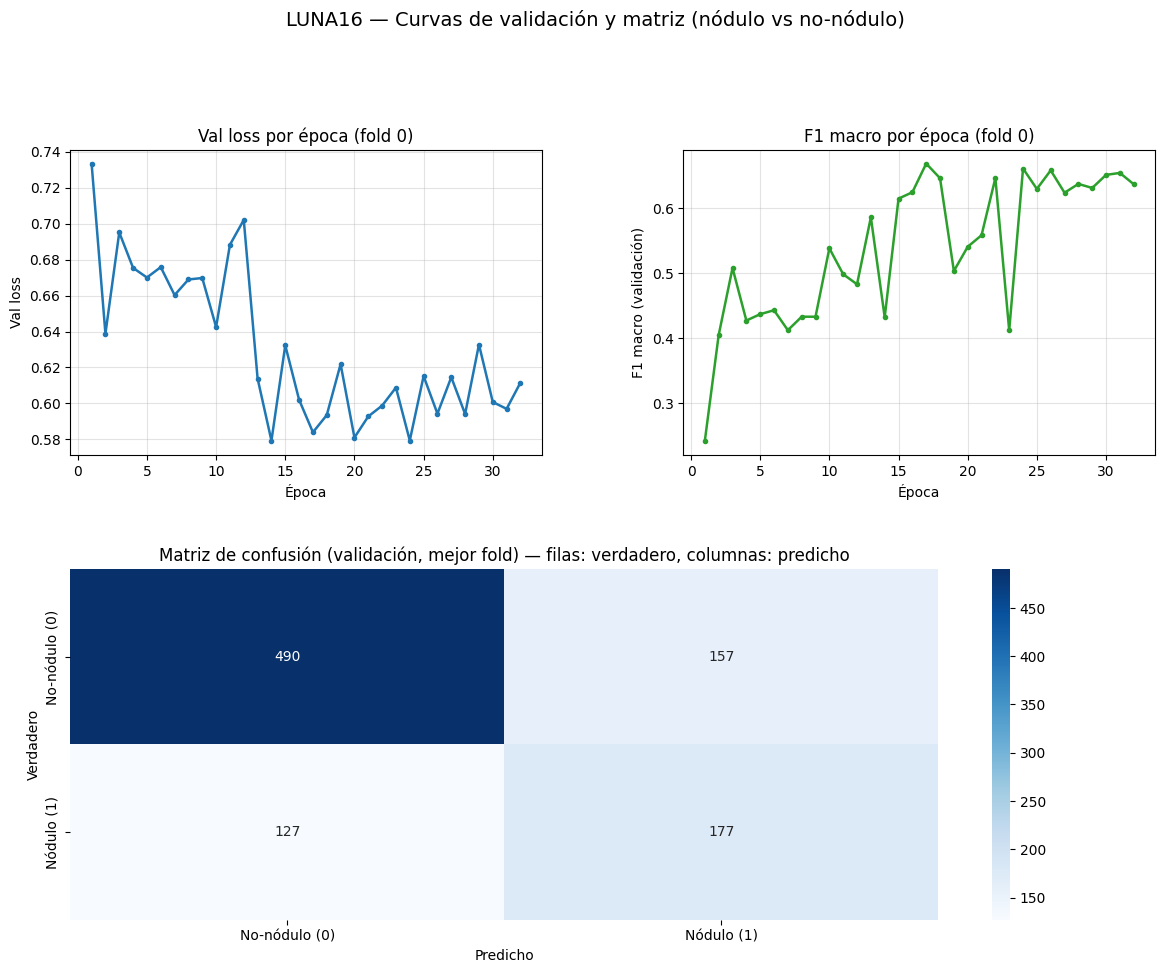

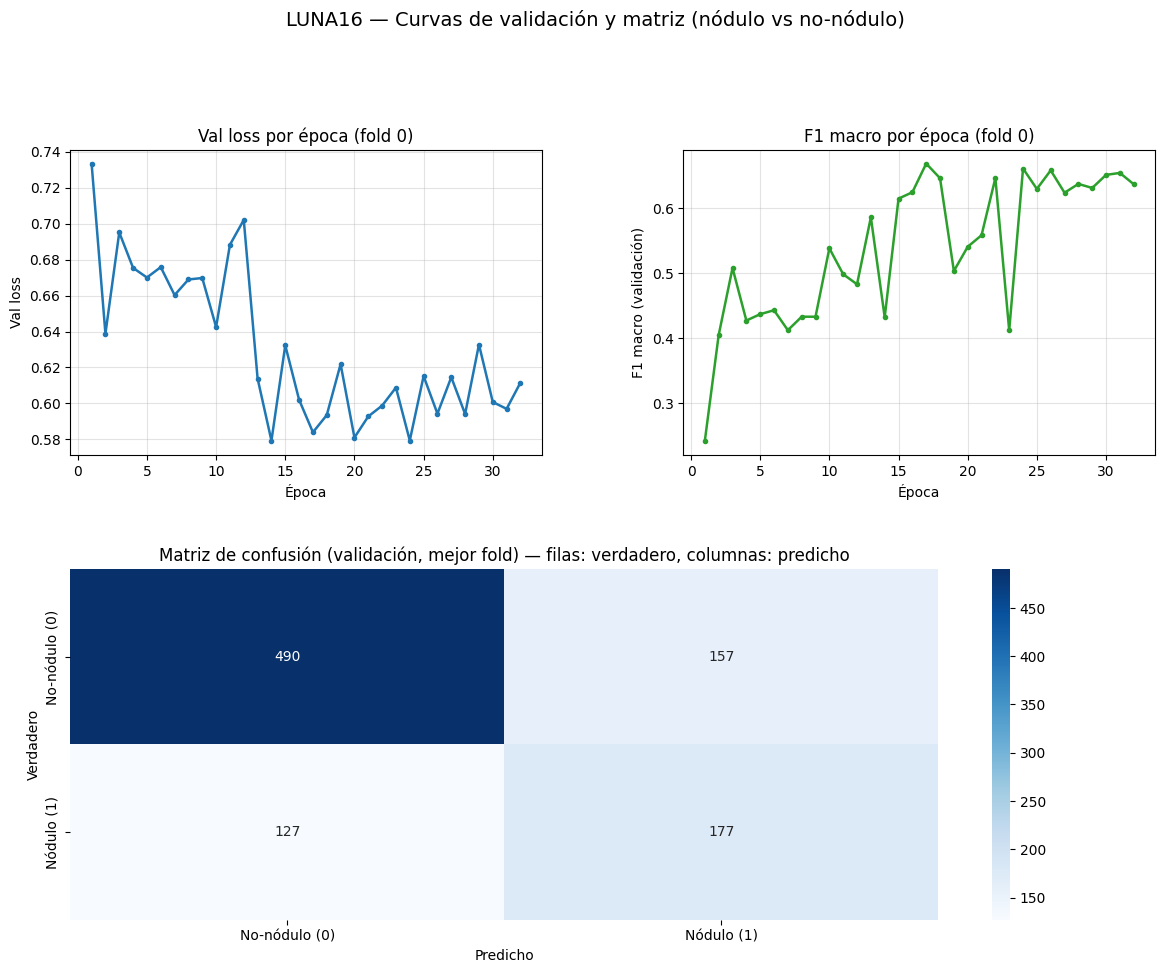

Figura guardada: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/figures/expert4_val_curves_confusion.png


In [20]:
# Fase 6B: Gráficas — val loss y F1-macro por época (mejor fold) + matriz de confusión
import json
import numpy as np
try:
    __import__("IPython").get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

if 'RUN_TAG' not in globals():
    RUN_TAG = 'twophase_wce_v1'

try:
    _bf = best_fold_idx
except NameError:
    summary_path = os.path.join(WEIGHTS_DIR, 'metrics', f'cv_summary_{RUN_TAG}.json')
    if not os.path.isfile(summary_path):
        summary_path = os.path.join(WEIGHTS_DIR, 'metrics', 'cv_summary.json')
    if os.path.isfile(summary_path):
        with open(summary_path, encoding='utf-8') as f:
            _summ = json.load(f)
        best_fold_idx = int(max(_summ, key=lambda m: m['best_val_f1'])['fold'])
    else:
        best_fold_idx = 0

hist_path = os.path.join(WEIGHTS_DIR, 'metrics', f'history_{RUN_TAG}_fold_{best_fold_idx}.json')
if not os.path.isfile(hist_path):
    _hist_alt = os.path.join(WEIGHTS_DIR, 'metrics', f'history_fold_{best_fold_idx}.json')
    hist_path = _hist_alt if os.path.isfile(_hist_alt) else hist_path
if not os.path.isfile(hist_path):
    raise FileNotFoundError(f"No existe {hist_path}. Ejecuta antes la Fase 5 (entrenamiento).")
with open(hist_path, encoding='utf-8') as f:
    hist = json.load(f)

try:
    cm_plot = cm
except NameError:
    eval_json = os.path.join(WEIGHTS_DIR, 'metrics', 'eval_best_fold.json')
    if os.path.isfile(eval_json):
        with open(eval_json, encoding='utf-8') as f:
            cm_plot = np.array(json.load(f)['confusion_matrix'])
    else:
        cm_plot = np.zeros((2, 2), dtype=int)

val_loss = hist['val_loss']
val_f1 = hist['val_f1']
epochs = np.arange(1, len(val_loss) + 1)

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.15], hspace=0.35, wspace=0.3)
ax_loss = fig.add_subplot(gs[0, 0])
ax_f1 = fig.add_subplot(gs[0, 1])
ax_cm = fig.add_subplot(gs[1, :])

ax_loss.plot(epochs, val_loss, color='#1f77b4', linewidth=1.8, marker='o', markersize=3)
ax_loss.set_xlabel('Época')
ax_loss.set_ylabel('Val loss')
ax_loss.set_title(f'Val loss por época (fold {best_fold_idx})')
ax_loss.grid(True, alpha=0.35)

ax_f1.plot(epochs, val_f1, color='#2ca02c', linewidth=1.8, marker='o', markersize=3)
ax_f1.set_xlabel('Época')
ax_f1.set_ylabel('F1 macro (validación)')
ax_f1.set_title(f'F1 macro por época (fold {best_fold_idx})')
ax_f1.grid(True, alpha=0.35)

sns.heatmap(
    cm_plot,
    annot=True,
    fmt='d',
    cmap='Blues',
        xticklabels=['No-nódulo (0)', 'Nódulo (1)'],
    yticklabels=['No-nódulo (0)', 'Nódulo (1)'],
    ax=ax_cm,
)
ax_cm.set_title('Matriz de confusión (validación, mejor fold) — filas: verdadero, columnas: predicho')
ax_cm.set_xlabel('Predicho')
ax_cm.set_ylabel('Verdadero')

plt.suptitle('LUNA16 — Curvas de validación y matriz (nódulo vs no-nódulo)', fontsize=14, y=1.02)
fig_path = os.path.join(WEIGHTS_DIR, 'figures', 'expert4_val_curves_confusion.png')
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
try:
    from IPython.display import display
    display(fig)
except Exception:
    pass
plt.show()
print(f"Figura guardada: {fig_path}")

GIF guardado: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/figures/gradcam_label0_no_nodulo_axial.gif


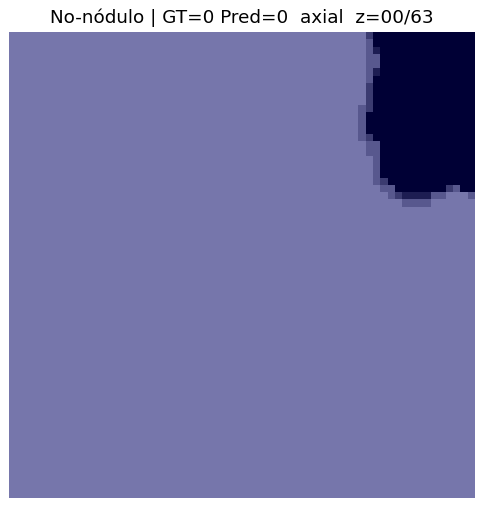

GIF guardado: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/figures/gradcam_label1_nodulo_axial.gif


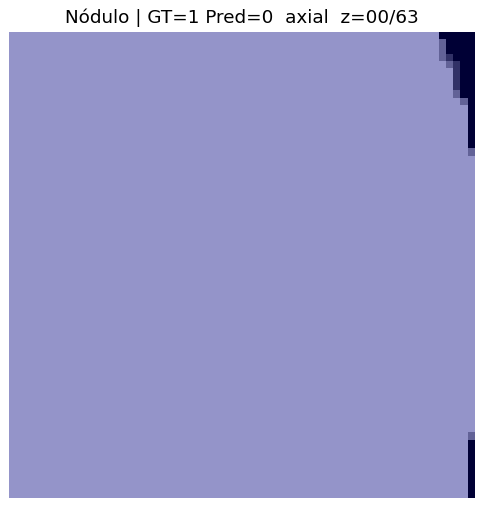

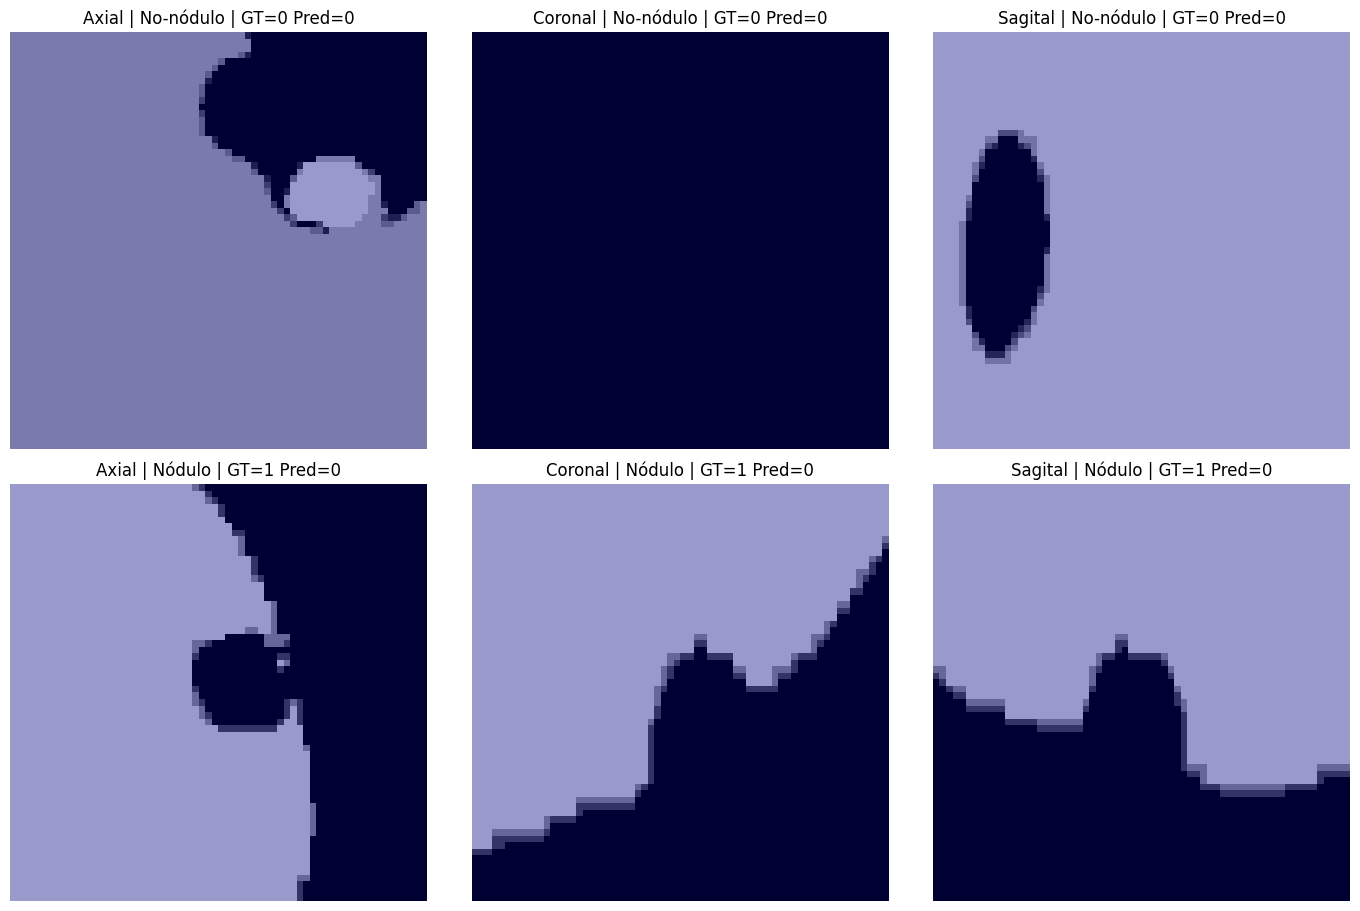

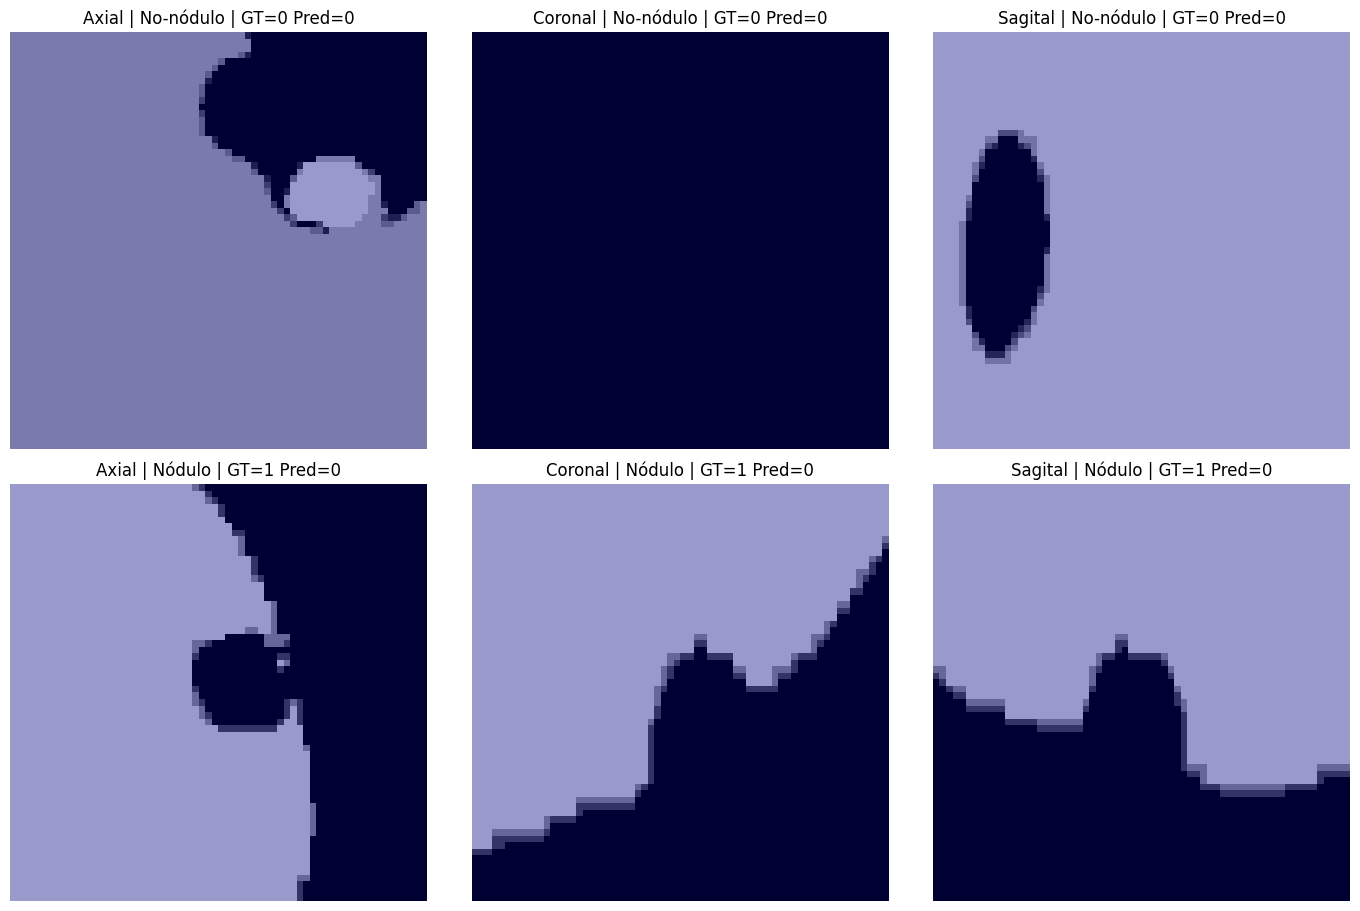

Figura estática (cortes centrales, no-nódulo vs nódulo): /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/figures/gradcam_no_nodulo_nodulo_mid_slices.png


In [21]:
# Fase 7: Grad-CAM 3D — capa `norm` de la rama Swin (DCSwinBStyle3D). La rama CNN R3D no participa en este mapa.
# Un ejemplo por clase en validación: mapa en todo el volumen + GIF axial (capa a capa) con la atención superpuesta.
try:
    __import__("IPython").get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import io
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.ndimage import zoom as ndzoom
from PIL import Image


class GradCAM3D:
    """Grad-CAM genérico para tensores (B,H,W,C) [Swin] o (B,C,D,H,W) [R3D]."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        self.activations = out.detach()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        x = x.clone().requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(logits)
        one_hot[0, class_idx] = 1.0
        logits.backward(gradient=one_hot)

        act = self.activations
        grad = self.gradients
        if act is None or grad is None:
            raise RuntimeError(
                "Grad-CAM: activaciones o gradientes None. "
                "Con gradient checkpointing a veces falla; prueba desactivar grad_checkpoint en Fase 4 solo para depurar."
            )

        if act.ndim == 4:
            weights = grad.mean(dim=[1, 2], keepdim=True)
            cam = (weights * act).sum(dim=-1)
        elif act.ndim == 5:
            weights = grad.mean(dim=[2, 3, 4], keepdim=True)
            cam = (weights * act).sum(dim=1)
        else:
            weights = grad.mean(dim=1, keepdim=True)
            cam = (weights * act).sum(dim=-1)

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam[0].cpu().numpy(), class_idx


def _cam_to_volume(cam_raw):
    """Interpola el mapa Grad-CAM al volumen 64³ (misma lógica que antes, cubriendo todo el volumen)."""
    if cam_raw.ndim == 2:
        cam_vol = ndzoom(cam_raw, np.array([64, 64]) / np.array(cam_raw.shape), order=1)
        cam_vol = np.stack([cam_vol] * 64, axis=0)
    elif cam_raw.ndim == 3:
        factors = np.array([64, 64, 64]) / np.array(cam_raw.shape)
        cam_vol = ndzoom(cam_raw, factors, order=1)
    else:
        cam_vol = np.zeros((64, 64, 64))
    return cam_vol.astype(np.float32)


def _find_val_index_per_class(dataset, n_classes=2):
    """Primer índice en el dataset de validación por cada etiqueta."""
    found = {c: None for c in range(n_classes)}
    for i in range(len(dataset)):
        _, y = dataset[i]
        yi = int(y.item()) if isinstance(y, torch.Tensor) else int(y)
        if yi in found and found[yi] is None:
            found[yi] = i
        if all(found[c] is not None for c in range(n_classes)):
            break
    return found


def _save_axial_gif(vol_np, cam_vol, out_path, title='', fps=10):
    """GIF recorriendo el eje Z (cortes axiales): CT en gris + Grad-CAM en jet."""
    D = vol_np.shape[0]
    vol_min, vol_max = float(vol_np.min()), float(vol_np.max())
    duration_ms = max(40, int(1000 / max(1, fps)))
    frames = []
    for z in range(D):
        fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=110)
        ax.imshow(vol_np[z], cmap='gray', vmin=vol_min, vmax=vol_max)
        ax.imshow(cam_vol[z], cmap='jet', alpha=0.42, vmin=0.0, vmax=1.0)
        ax.set_title(f'{title}  axial  z={z:02d}/{D - 1}')
        ax.axis('off')
        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.08, facecolor='white')
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert('RGB'))
    frames[0].save(
        out_path, save_all=True, append_images=frames[1:],
        duration=duration_ms, loop=0,
    )


if hasattr(eval_model, 'norm'):
    target = eval_model.norm
elif hasattr(eval_model, 'backbone'):
    children = list(eval_model.backbone.children())
    target = children[-2] if len(children) > 1 else children[-1]
else:
    target = list(eval_model.modules())[-2]

gradcam = GradCAM3D(eval_model, target)

idx_by_class = _find_val_index_per_class(val_ds_best, n_classes=2)
fig_dir = os.path.join(WEIGHTS_DIR, 'figures')
os.makedirs(fig_dir, exist_ok=True)

# Etiquetas: 0 = no-nódulo, 1 = nódulo (track FP; no es benigno/maligno).
name_map = {0: 'label0_no_nodulo', 1: 'label1_nodulo'}
label_txt = {0: 'No-nódulo', 1: 'Nódulo'}

results = {}
for cls in (0, 1):
    si = idx_by_class.get(cls)
    if si is None:
        print(f"AVISO: no hay muestra de validación con etiqueta {cls}; no se genera GIF para esa clase.")
        continue
    x_sample, y_sample = val_ds_best[si]
    x_gpu = x_sample.unsqueeze(0).to(DEVICE)
    try:
        cam_raw, pred_cls = gradcam(x_gpu)
        cam_vol = _cam_to_volume(cam_raw)
    except Exception as e:
        print(f"Grad-CAM error (clase {cls}, índice {si}): {e}")
        continue

    if isinstance(x_sample, torch.Tensor):
        vol_np = x_sample.squeeze().detach().cpu().numpy()
    else:
        vol_np = np.asarray(x_sample).squeeze()

    results[cls] = {
        'vol_np': vol_np,
        'cam_vol': cam_vol,
        'pred_cls': int(pred_cls),
        'y_sample': int(y_sample),
        'idx': si,
    }

for cls in sorted(results.keys()):
    r = results[cls]
    gif_path = os.path.join(fig_dir, f'gradcam_{name_map[cls]}_axial.gif')
    title = f'{label_txt[cls]} | GT={r["y_sample"]} Pred={r["pred_cls"]}'
    _save_axial_gif(r['vol_np'], r['cam_vol'], gif_path, title=title, fps=10)
    print(f"GIF guardado: {gif_path}")
    try:
        from IPython.display import Image as IPImage, display
        display(IPImage(filename=gif_path))
    except Exception as ex:
        print(f"(No se pudo incrustar el GIF: {ex})")

# Vista estática: cortes centrales (axial / coronal / sagital) por cada ejemplo
if results:
    n_plot = len(results)
    fig, axes = plt.subplots(n_plot, 3, figsize=(14, 4.6 * max(1, n_plot)))
    if n_plot == 1:
        axes = np.asarray(axes).reshape(1, 3)
    for row, cls in enumerate(sorted(results.keys())):
        r = results[cls]
        vol_np, cam_vol = r['vol_np'], r['cam_vol']
        mid = [s // 2 for s in vol_np.shape]
        _pc = r['pred_cls']
        slices_info = [
            ('Axial', vol_np[mid[0]], cam_vol[mid[0]]),
            ('Coronal', vol_np[:, mid[1]], cam_vol[:, mid[1]]),
            ('Sagital', vol_np[:, :, mid[2]], cam_vol[:, :, mid[2]]),
        ]
        for j, (name, sl, cam_sl) in enumerate(slices_info):
            axes[row, j].imshow(sl, cmap='gray')
            axes[row, j].imshow(cam_sl, cmap='jet', alpha=0.4)
            axes[row, j].set_title(f"{name} | {label_txt[cls]} | GT={r['y_sample']} Pred={_pc}")
            axes[row, j].axis('off')
    plt.tight_layout()
    gradcam_png = os.path.join(fig_dir, 'gradcam_no_nodulo_nodulo_mid_slices.png')
    plt.savefig(gradcam_png, dpi=150, bbox_inches='tight')
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        pass
    plt.show()
    print(f"Figura estática (cortes centrales, no-nódulo vs nódulo): {gradcam_png}")


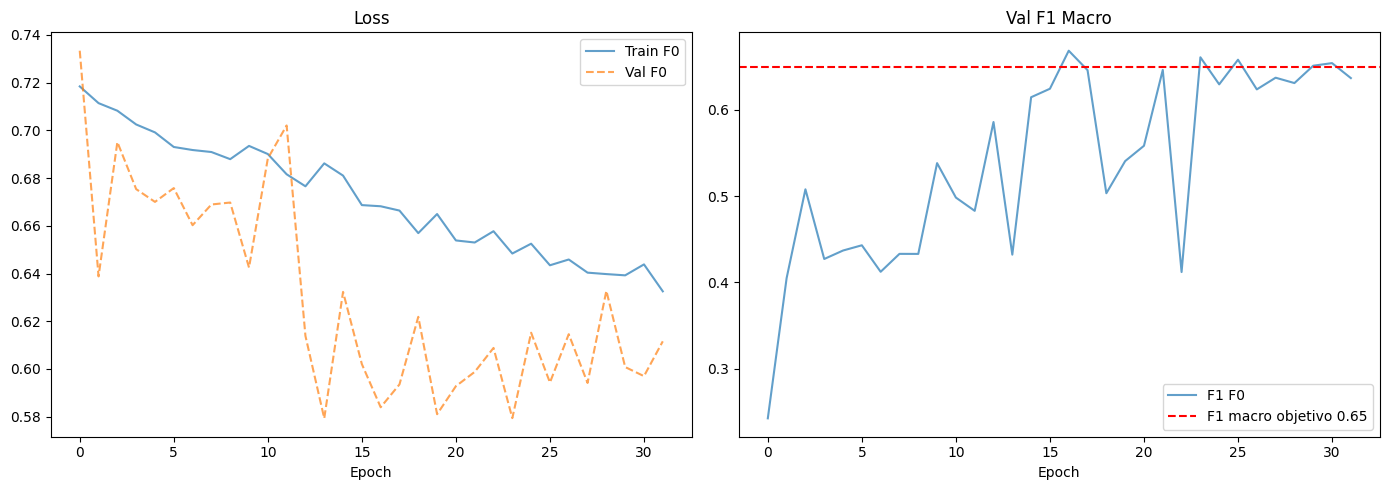

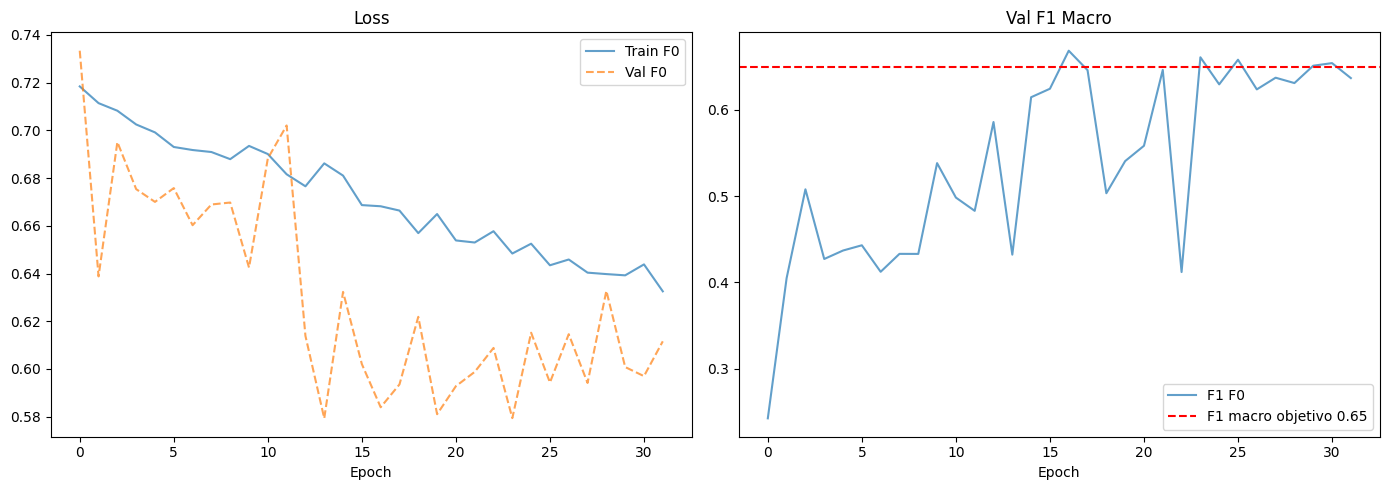

Curvas guardadas en /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/figures/training_curves.png


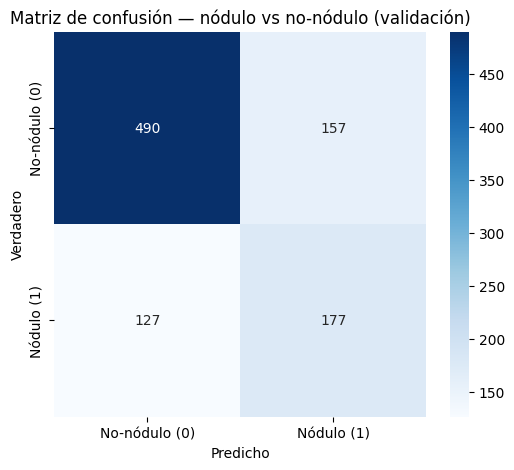

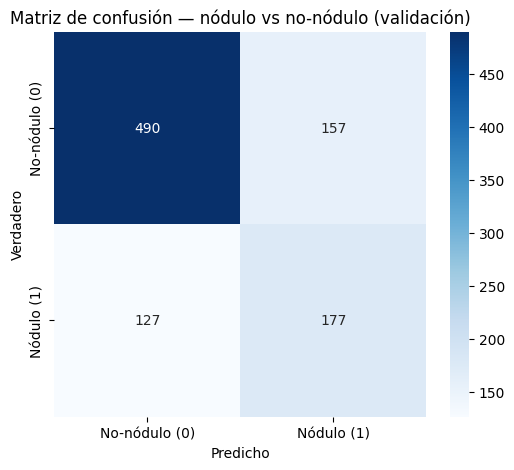

CM guardada en /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/figures/confusion_matrix.png


In [22]:
# Fase 8: Figuras de entrenamiento (curvas por fold)
if 'RUN_TAG' not in globals():
    RUN_TAG = 'twophase_wce_v1'

import json
import numpy as np
try:
    __import__("IPython").get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = os.path.join(WEIGHTS_DIR, 'figures')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for fold_idx in range(N_FOLDS):
    hp = os.path.join(WEIGHTS_DIR, 'metrics', f'history_{RUN_TAG}_fold_{fold_idx}.json')
    if not os.path.isfile(hp):
        hp = os.path.join(WEIGHTS_DIR, 'metrics', f'history_fold_{fold_idx}.json')
    if not os.path.isfile(hp):
        continue
    with open(hp) as f:
        h = json.load(f)
    axes[0].plot(h['train_loss'], label=f'Train F{fold_idx}', alpha=0.7)
    axes[0].plot(h['val_loss'], '--', label=f'Val F{fold_idx}', alpha=0.7)
    axes[1].plot(h['val_f1'], label=f'F1 F{fold_idx}', alpha=0.7)

axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Val F1 Macro'); axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[1].axhline(y=0.65, color='red', linestyle='--', label='F1 macro objetivo 0.65')
axes[1].legend()

plt.tight_layout()
curves_path = os.path.join(fig_dir, 'training_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
try:
    from IPython.display import display
    display(fig)
except Exception:
    pass
plt.show()
print(f"Curvas guardadas en {curves_path}")

# Confusion matrix heatmap
try:
    cm_f8 = cm
except NameError:
    _ep = os.path.join(WEIGHTS_DIR, 'metrics', 'eval_best_fold.json')
    if os.path.isfile(_ep):
        with open(_ep, encoding='utf-8') as f:
            cm_f8 = np.array(json.load(f)['confusion_matrix'])
    else:
        cm_f8 = np.zeros((2, 2), dtype=int)

fig_cm = plt.figure(figsize=(6, 5))
sns.heatmap(cm_f8, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['No-nódulo (0)', 'Nódulo (1)'],
            yticklabels=['No-nódulo (0)', 'Nódulo (1)'])
plt.title('Matriz de confusión — nódulo vs no-nódulo (validación)')
plt.xlabel('Predicho'); plt.ylabel('Verdadero')
cm_path = os.path.join(fig_dir, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
try:
    from IPython.display import display
    display(fig_cm)
except Exception:
    pass
plt.show()
print(f"CM guardada en {cm_path}")


In [23]:
# Fase 9: Resumen final y persistencia
if 'RUN_TAG' not in globals():
    RUN_TAG = 'twophase_wce_v1'
print("="*60)
print("EXPERTO 4 — LUNA16 SWIN3D — RESUMEN")
print("="*60)
print(f"RUN_TAG (prefijo checkpoints): {RUN_TAG}")

print(f"\nModelo: {'DCSwinBStyle3D' if USE_DCSWIN_STYLE else 'R3D-18'}")
print(f"Parámetros: {n_params:,}")
print(f"Folds: {N_FOLDS} (5–10 reduce varianza; criterio F1 sobre media±std en CV)")
print(f"Épocas/fold (máx.): Fase A {PHASE_A_EPOCHS} + Fase B {PHASE_B_EPOCHS} = {TOTAL_EPOCHS_PER_FOLD} (early stop en B)")
print(f"Batch size: {BATCH_SIZE}, accum: {ACCUM_STEPS}")
print(f"LR: Fase A cabeza={LR_HEAD_PHASE_A}; Fase B Swin/CNN/head={LR_SWIN_B}/{LR_CNN_B}/{LR_HEAD_B} | WD: {WD}")
print(f"AMP: {AMP_ENABLED}")
print(f"Device: {DEVICE}")

print(f"\nMétricas CV:")
for m in all_fold_metrics:
    print(f"  Fold {m['fold']}: F1={m['best_val_f1']:.4f}")

f1s = [m['best_val_f1'] for m in all_fold_metrics]
print(f"  Media: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

print(f"\nArtefactos en Drive:")
print(f"  {WEIGHTS_DIR}")
for root, dirs, files in os.walk(WEIGHTS_DIR):
    for f_name in files:
        fp = os.path.join(root, f_name)
        sz = os.path.getsize(fp) / 1024
        print(f"    {os.path.relpath(fp, WEIGHTS_DIR):50s} {sz:.1f} KB")

print("\nExperto 4 listo para integración MoE.")
print("Tensor de entrada esperado: [B, 1, 64, 64, 64]")
print("Salida: logits [B, 2] (benigno/maligno)")


EXPERTO 4 — LUNA16 SWIN3D — RESUMEN
RUN_TAG (prefijo checkpoints): twophase_wce_v1

Modelo: DCSwinBStyle3D
Parámetros: 29,535,548
Folds: 5 (5–10 reduce varianza; criterio F1 sobre media±std en CV)
Épocas/fold (máx.): Fase A 8 + Fase B 42 = 50 (early stop en B)
Batch size: 4, accum: 1
LR: Fase A cabeza=0.001; Fase B Swin/CNN/head=3e-05/5e-05/0.0001 | WD: 0.01
AMP: True
Device: cuda

Métricas CV:
  Fold 0: F1=0.6686
  Media: 0.6686 ± 0.0000

Artefactos en Drive:
  /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16
    checkpoints/expert4_twophase_wce_v1_fold0_best.pth 115475.1 KB
    checkpoints/expert4_twophase_wce_v1_fold1_best.pth 115475.1 KB
    metrics/history_twophase_wce_v1_fold_0.json        5.9 KB
    metrics/eval_best_fold.json                        0.2 KB
    figures/expert4_val_curves_confusion.png           163.5 KB
    figures/gradcam_samples.png                        66.5 KB
    figures/training_curves.png                        122.7 KB
    